In [1]:
import sys
from itertools import combinations
from pathlib import Path
from statistics import correlation, mean

import litellm
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from tabulate import tabulate
from wordfreq import zipf_frequency
from words import get_words

# Add the repo root to sys.path so we can import our modules
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from GenerateKeywordCards2.async_rng import AsyncRng
from GenerateKeywordCards2.check_familiarity import check_familiarity_async

# from asyncio import TaskGroup  <-- Doesn't work in Jupyter, use CompatTaskGroup instead.
from GenerateKeywordCards2.compat_task_group import CompatTaskGroup as TaskGroup
from GenerateKeywordCards2.llm import small_models
from GenerateKeywordCards2.manual_ratings import (
    add_manual_ratings_words,
    get_manual_ratings,
)
from GenerateKeywordCards2.rate_words import rate_words
from GenerateKeywordCards2.rate_words_with_variations import (
    ModelParams,
    RateWordsWithVariationsResult,
    VariationParams,
    VariationView,
    iter_variation_views,
    rate_words_with_variations,
)

In [2]:
litellm.cache = litellm.Cache(type="disk")

# Words

Get a large set of words in descending order of frequency. List examples of words at various positions in the list.

Most words become obscure or strange at around position 20,000 but some very recognizable words remaineven at position 50,000.

In [3]:
all_words = get_words()

step = 5_000
segment_size = 20
indices = list(range(0, len(all_words) - segment_size, step))
if indices[-1] != len(all_words) - segment_size:
    indices.append(len(all_words) - segment_size)
for i in indices:
    segment = all_words[i : i + segment_size]
    frequency = zipf_frequency(segment[0], "en")
    print(f"{i} ({frequency}): {segment}")

0 (7.73): ['the', 'to', 'and', 'of', 'a', 'in', 'i', 'is', 'for', 'that', 'you', 'it', 'on', 'with', 'this', 'was', 'be', 'as', 'are', 'have']
5000 (4.21): ['aims', 'arc', 'backup', 'beaten', 'bitter', 'blown', 'branches', 'campaigns', 'chips', 'cia', 'clever', 'clinic', 'closest', 'collections', 'continuous', 'converted', 'correctly', 'creator', 'creatures', 'criteria']
10000 (3.77): ['chop', 'circuits', 'clifford', 'co2', 'cody', 'coleman', 'commanded', 'commissioners', 'communicating', 'comparative', 'complement', 'connor', 'conquer', 'conquest', 'contested', 'continuity', 'cornwall', 'crawl', 'credible', 'cursed']
15000 (3.5): ['paycheck', 'peaches', 'peaked', 'picturesque', 'pilgrimage', 'pillows', 'pivot', 'pivotal', 'por', 'pressured', 'preventive', 'primer', 'profitability', 'progressing', 'provoke', 'ps3', 'pulmonary', 'punishing', 'rad', 'radicals']
20000 (3.28): ['assay', 'assigning', 'assorted', 'axel', 'badminton', 'barbarian', 'bedrock', 'bihar', 'bj', 'blaine', 'boardwal

# Check familiarity

Are the various models familiar with the game So Clover!?

In [4]:
total_metadata = 0
tasks_by_model_params = {}
async with TaskGroup() as tg:
    for model in small_models:
        tasks_by_model_params[model] = tg.create_task(
            check_familiarity_async(model), eager_start=True
        )

for model, task in tasks_by_model_params.items():
    familiarity, metadata = task.result()
    total_metadata += metadata
    familiarity_str = familiarity.replace("\n", " ")
    print(
        f"{model} ${metadata.total_cost:.4f} {metadata.output_tokens} output tokens: {familiarity_str}"
    )

print(total_metadata)


Provider List: https://docs.litellm.ai/docs/providers

openai/gpt-5.4-mini-2026-03-17 $0.0084 1847 output tokens: Yes — So Clover is a great fit for carefully chosen keywords, because the whole game lives or dies on how *clueable* and *distinctive* the words are.  If you’re making an expansion of keyword cards, the best words are not just “interesting,” but **good clue magnets**: words that can be connected in multiple ways without being too broad, too obscure, or too easily confused with other cards.  ## What qualities to look for in keywords  ### 1. **They should support multiple clue paths** The best words can be hinted at from several angles: - meaning - category - function - appearance - sound/wordplay - common associations - opposite/contrast  Example: **“Bridge”** can be clued via: - architecture - cards - over water - connecting two things - “crossing”  That flexibility helps players build a clue that hits two cards at once.  ---  ### 2. **They should be familiar, but not too 

# Sample Ratings

Rate a representative set of words in a variety of ways to measure how well they will work as So Clover! keywords.

In [5]:
# Initially, rate a small number of words with all small models.
initial_number_of_words = 3000

# Include the base game's words
existing_keywords_file = (
    repo_root / "GenerateKeywordCards" / "CloverExistingKeywords.csv"
)
existing_keywords = existing_keywords_file.read_text(encoding="utf-8-sig").splitlines()
existing_keywords = [w.lower() for w in existing_keywords]
assert len(existing_keywords) <= initial_number_of_words

# Sample remaining words from all_words
existing_keywords_set = set(existing_keywords)
all_words_without_existing = [w for w in all_words if w not in existing_keywords_set]
local_rng = AsyncRng(123).unwrap()
sampled_keywords = local_rng.sample(
    all_words_without_existing, k=initial_number_of_words - len(existing_keywords)
)

duplicate_words = sorted(set(existing_keywords) & set(sampled_keywords))
# CONSIDER: Remove the duplicate words from sampled_keywords. Wish I had done this before rating.
print(
    f"Warning: {len(duplicate_words)} duplicate words in both existing and sampled keywords. {duplicate_words}"
)

print(
    f"Rating {len(existing_keywords)} existing keywords and {len(sampled_keywords)} new keywords with all small models."
)
initial_words = existing_keywords + sampled_keywords

models_params = [
    ModelParams(
        model="openai/gpt-5.4-mini-2026-03-17",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
    # ModelParams(
    #     model="anthropic/claude-haiku-4-5-20251001",
    #     reasoning_effort="low",
    #     batch_size=50,
    # ),
    ModelParams(
        model="gemini/gemini-3-flash-preview",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=50,
    ),
    # ModelParams(
    #     model="deepseek/deepseek-v4-flash",
    #     reasoning_effort="none",
    #     batch_size=300,
    # ),
]

prompt_names = [
    # "simple",
    # "gameplay",
    # "associations",
    "aspects_detailed",
]
results_by_variation = await rate_words_with_variations(
    models_params, prompt_names, initial_words
)

Rating 880 existing keywords and 2120 new keywords with all small models.
* Rating openai/gpt-5.4-mini-2026-03-17 none 300 100 aspects_detailed...
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [ike...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [ike...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [makings...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [makings...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [berger...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [berger...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [commissary...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [commissary...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [hello...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [hello...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [unif

In [6]:
print("Variation cost:")

total_metadata = 0
for variation in sorted(results_by_variation.keys()):
    variation_result = results_by_variation[variation]
    total_metadata += variation_result.metadata
    print(variation)
    print(
        f"  ${variation_result.metadata.total_cost:.4f} {variation_result.metadata.output_tokens:,} output tokens {variation_result.metadata.reasoning_tokens:,} reasoning tokens",
        flush=True,
    )

print(total_metadata)

Variation cost:
gemini/gemini-3-flash-preview none 300 50 aspects_detailed
  $0.8592 275,819 output tokens 0 reasoning tokens
openai/gpt-5.4-mini-2026-03-17 none 300 100 aspects_detailed
  $1.2695 274,177 output tokens 0 reasoning tokens
31/93 cache hits, $0.8592 uncached cost, $2.1286 total cost, 549,996 output tokens


In [7]:
for variation_view in iter_variation_views(results_by_variation):
    variation_result = variation_view.variation_result
    print(variation_view.short_str())

    sorted_by_ratings = sorted(
        initial_words,
        key=lambda w: variation_view.overall_rating(w),
        reverse=True,
    )
    number_of_examples = 10
    print(f"  best: {sorted_by_ratings[:number_of_examples]}")
    print(f"  worst: {sorted_by_ratings[-number_of_examples:]}")
    average_rating_existing_keywords = mean(
        variation_view.overall_rating(w) for w in existing_keywords
    )
    average_rating_new_keywords = mean(
        variation_view.overall_rating(w) for w in sampled_keywords
    )
    print(
        f"  average rating: existing keywords={average_rating_existing_keywords:.1f}, new keywords={average_rating_new_keywords:.1f}"
    )

print(total_metadata)

gemini-3-flash-preview aspects_detailed [assoc]
  best: ['air', 'animal', 'apple', 'arm', 'baby', 'balance', 'ball', 'bar', 'bear', 'bed']
  worst: ['hauser', 'pid', 'apd', 'pn', 'thurston', "get's", 'yoy', 'hutchins', 'tk', 'cts']
  average rating: existing keywords=8.5, new keywords=5.2
gemini-3-flash-preview aspects_detailed [gamepl]
  best: ['angel', 'animal', 'apple', 'arm', 'astronaut', 'baby', 'balance', 'ball', 'banana', 'bar']
  worst: ['thi', 'hauser', 'pid', 'apd', 'pn', 'meps', "get's", 'yoy', 'tk', 'cts']
  average rating: existing keywords=8.6, new keywords=5.5
gpt-5.4-mini aspects_detailed [assoc]
  best: ['apple', 'ball', 'face', 'head', 'heart', 'key', 'line', 'love', 'star', 'sun']
  worst: ['fj', 'husain', 'tasha', 'anderson', 'rafe', 'warburg', 'ots', 'bogdan', 'fabrizio', 'uab']
  average rating: existing keywords=6.7, new keywords=3.7
gpt-5.4-mini aspects_detailed [gamepl]
  best: ['ball', 'face', 'head', 'heart', 'key', 'love', 'star', 'sun', 'apple', 'baby']
  w

In [8]:
print(
    "Correlation between ratings of each model/variation with each other model/variation:\n"
)

rows = []
for iA, variation_view_A in enumerate(iter_variation_views(results_by_variation)):
    row = [variation_view_A.short_str()]
    for iB, variation_view_B in enumerate(iter_variation_views(results_by_variation)):
        if iA == iB:
            row.append("")
            continue

        ratings_A_list = [variation_view_A.overall_rating(w) for w in initial_words]
        ratings_B_list = [variation_view_B.overall_rating(w) for w in initial_words]
        # TODO: Use improved percentage-based ratings instead of 1-10 ratings for better correlation independent from abolute rating values.
        correlation_value = correlation(ratings_A_list, ratings_B_list)
        row.append(f"{correlation_value}")
    rows.append(row)

header = [""] + [
    variation_view.short_str()
    for variation_view in iter_variation_views(results_by_variation)
]
print(tabulate(rows, headers=header, tablefmt="github", floatfmt=".2f"))

Correlation between ratings of each model/variation with each other model/variation:

|                                                  |   gemini-3-flash-preview aspects_detailed [assoc] |   gemini-3-flash-preview aspects_detailed [gamepl] |   gpt-5.4-mini aspects_detailed [assoc] |   gpt-5.4-mini aspects_detailed [gamepl] |
|--------------------------------------------------|---------------------------------------------------|----------------------------------------------------|-----------------------------------------|------------------------------------------|
| gemini-3-flash-preview aspects_detailed [assoc]  |                                                   |                                               0.97 |                                    0.84 |                                     0.87 |
| gemini-3-flash-preview aspects_detailed [gamepl] |                                              0.97 |                                                    |                            

Histograms of ratings for new and existing keywords, for each model and variation:


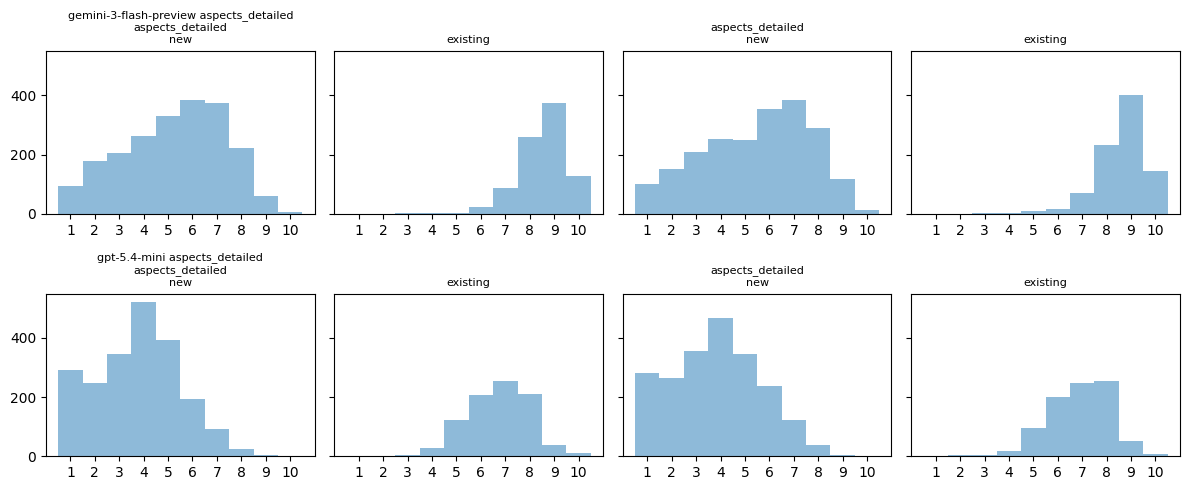

In [9]:
print(
    "Histograms of ratings for new and existing keywords, for each model and variation:"
)

variations_per_row = 2
variation_view_count = len(list(iter_variation_views(results_by_variation)))
assert variation_view_count % variations_per_row == 0
fig, axes = plt.subplots(
    nrows=variation_view_count // variations_per_row,
    ncols=2 * variations_per_row,
    figsize=(12, 2.5 * (variation_view_count // variations_per_row)),
    sharex=True,
    sharey=True,
    squeeze=False,
)
for i_variation, variation_view in enumerate(
    iter_variation_views(results_by_variation)
):
    ratings_existing_keywords = [
        variation_view.overall_rating(w) for w in existing_keywords
    ]
    ratings_new_keywords = [
        variation_view.overall_rating(w) for w in sampled_keywords
    ]
    for is_new in [True, False]:
        i_column = (i_variation % variations_per_row) * 2 + (0 if is_new else 1)
        ax = axes[i_variation // variations_per_row, i_column]
        ratings = ratings_new_keywords if is_new else ratings_existing_keywords
        ax.hist(ratings, bins=range(1, 12), alpha=0.5)
        ax.set_xticks([x + 0.5 for x in range(1, 11)], labels=range(1, 11))
        ax.tick_params(axis="x", labelbottom=True)
        title_model = variation_view.variation_params.short_str() if i_column == 0 else ""
        title_prompt = variation_view.variation_params.prompt_name if is_new else ""
        title_keywords = "new" if is_new else "existing"
        title = f"{title_model}\n{title_prompt}\n{title_keywords}"
        ax.set_title(title, fontsize=8)

fig.tight_layout()
plt.show()

In [10]:
def get_percentage_of_existing_rated_higher_than_sampled(
    variation_view: VariationView,
) -> float:
    count_existing_higher = 0
    for w_existing in existing_keywords:
        rating_existing = variation_view.overall_rating(w_existing)
        for w_sampled in sampled_keywords:
            rating_new = variation_view.overall_rating(w_sampled)
            if rating_existing > rating_new:
                count_existing_higher += 1
    total_comparisons = len(existing_keywords) * len(sampled_keywords)
    if total_comparisons == 0:
        return 0.0
    percentage = (count_existing_higher / total_comparisons) * 100
    return percentage


print(
    "Percentage of comparisons where existing keywords are rated higher than new keywords:"
)
rows = []
for variation_view in iter_variation_views(results_by_variation):
    percentage = get_percentage_of_existing_rated_higher_than_sampled(variation_view)
    rows.append([variation_view.short_str(), percentage])
print(tabulate(rows, tablefmt="github", floatfmt=".1f"))

Percentage of comparisons where existing keywords are rated higher than new keywords:
|--------------------------------------------------|------|
| gemini-3-flash-preview aspects_detailed [assoc]  | 89.6 |
| gemini-3-flash-preview aspects_detailed [gamepl] | 86.7 |
| gpt-5.4-mini aspects_detailed [assoc]            | 87.5 |
| gpt-5.4-mini aspects_detailed [gamepl]           | 87.4 |


# Manual Ratings

Manually rate words for which there is disagreement of the LLMs.

In [11]:
percentile_ranks_by_variation = {}
for variation_view in iter_variation_views(results_by_variation):
    ratings = [variation_view.overall_rating(w) for w in initial_words]
    ranks = rankdata(ratings, method="average")
    percentiles = [(r - 1) / (len(ranks) - 1) * 100 for r in ranks]
    percentile_ranks_by_variation[variation_view.get_hash_key()] = dict(zip(initial_words, percentiles))

mean_pairwise_percentile_difference_by_word = {}
for word in initial_words:
    percentiles = [
        percentile_ranks_by_variation[variation_view.get_hash_key()][word]
        for variation_view in iter_variation_views(results_by_variation)
    ]
    pair_differences = [abs(a - b) for a, b in combinations(percentiles, 2)]
    mean_pairwise_percentile_difference_by_word[word] = mean(pair_differences)

initial_words_sorted_by_consistency = sorted(
    initial_words, key=lambda w: mean_pairwise_percentile_difference_by_word[w]
)


def tabulate_difference_details(words: list[str]):
    mean_percentile_by_word = {}
    for word in words:
        mean_percentile_by_word[word] = mean(
            [
                percentile_ranks_by_variation[variation_view.get_hash_key()][word]
                for variation_view in iter_variation_views(results_by_variation)
            ]
        )

    # Sort words by mean percentile, from highest to lowest.
    # This makes it easier to read the table to interpret high/low quality words next to one another.
    sorted_words = sorted(words, key=lambda w: mean_percentile_by_word[w], reverse=True)

    header = ["Variation"] + sorted_words
    rows = []

    rows.append(
        ["Mean Rating"] + [mean_percentile_by_word[word] for word in sorted_words]
    )

    rows.append(
        ["Mean Difference"]
        + [mean_pairwise_percentile_difference_by_word[word] for word in sorted_words]
    )

    for variation_view in iter_variation_views(results_by_variation):
        row = [variation_view.short_str()]
        for word in sorted_words:
            percentile = percentile_ranks_by_variation[variation_view.get_hash_key()][word]
            row.append(percentile)
        rows.append(row)

    print(tabulate(rows, headers=header, tablefmt="github", floatfmt=".1f"))


number_of_consitency_examples = 25
print("Least consistent words:")
tabulate_difference_details(
    initial_words_sorted_by_consistency[-number_of_consitency_examples:]
)
print("\nMost consistent words:")
tabulate_difference_details(
    initial_words_sorted_by_consistency[:number_of_consitency_examples]
)

number_of_manual_ratings = 50
add_manual_ratings_words(
    initial_words_sorted_by_consistency[-number_of_manual_ratings:]
)

Least consistent words:
| Variation                                        |   leadership |   mat |   shamans |   display |   star's |   illness |   series |   waldo |   hubble |   sistine |   put |   reshaping |   multidimensional |   by |   john |   cher |   concept |   bank's |   sort |   unfulfilled |   armstrong |   connery |   mahal |   berkley |   micky |
|--------------------------------------------------|--------------|-------|-----------|-----------|----------|-----------|----------|---------|----------|-----------|-------|-------------|--------------------|------|--------|--------|-----------|----------|--------|---------------|-------------|-----------|---------|-----------|---------|
| Mean Rating                                      |         68.1 |  67.2 |      63.1 |      61.7 |     61.5 |      56.1 |     53.0 |    52.0 |     52.0 |      52.0 |  49.9 |        48.3 |               47.4 | 45.4 |   45.1 |   44.7 |      44.1 |     41.6 |   41.6 |          41.4 |        41.2

In [12]:
manual_ratings = get_manual_ratings()
manual_ratings_words = sorted(manual_ratings.keys())

manual_percentile_ranks_by_field = {}

# Rating fields should be the same for all words
rating_fields = set(manual_ratings[manual_ratings_words[0]].keys())
for word in manual_ratings_words:
    assert set(manual_ratings[word].keys()) == rating_fields

for field in rating_fields:
    ratings = [manual_ratings[w][field] for w in manual_ratings_words]
    ranks = rankdata(ratings, method="average")
    percentiles = [(r - 1) / (len(ranks) - 1) * 100 for r in ranks]
    manual_percentile_ranks_by_field[field] = dict(
        zip(manual_ratings_words, percentiles)
    )

print("Average difference in percentile rank between manual ratings and model ratings:")
rows = []
fields_to_display = ["Association Overall", "Gameplay Overall"]
for variation in variations:
    row = []
    for field in fields_to_display:
        variation_result = results_by_variation[variation]
        total_difference = 0.0
        for word in manual_ratings_words:
            manual_percentile = manual_percentile_ranks_by_field[field][word]
            model_percentile = percentile_ranks_by_variation[variation][word]
            total_difference += abs(manual_percentile - model_percentile)
        average_difference = total_difference / len(manual_ratings_words)
        if row == []:
            row.append(variation.short_str())
        row.append(average_difference)
    rows.append(row)

print(
    tabulate(
        rows,
        headers=["Variation"] + fields_to_display,
        tablefmt="github",
        floatfmt=".1f",
    )
)

ValueError: The ratings in manual_ratings.csv are incomplete for the following 48 words: armstrong, bank's, berkley, by, cher, chlorophyll, coincidences, concept, connery, display, forgery, froze, grate, group, hubble, illness, john, keller, lady, leadership, libretto, m.d, mahal, mat, micky, multidimensional, orchestration, paraphrasing, polynesia, pope's, registration, repair, reshaping, ronaldo, series, shamans, ship's, shrunk, sistine, sort, star's, symbolized, unfulfilled, vat, victimization, waldo, wilhelm, xp

# PIP Audit

Security check for packages that need to be updated.

In [ ]:
!pip-audit
# TODO: There is currently a vulnerability GHSA-r7w7-9xr2-qq2r in langchain-openai.
# However, I cannot update to the latest version because the updated langchain-openai requires openai>=2.24 bu the latest stable litellm hard-pins openai==2.24.0.